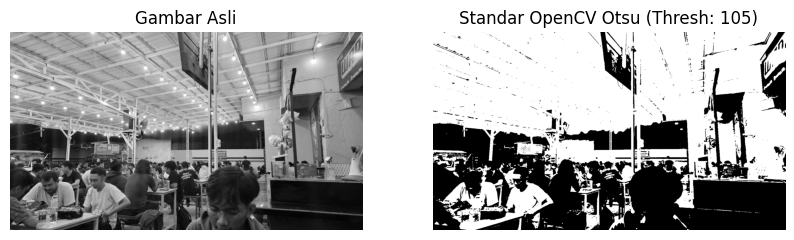


===== Memulai Eksperimen: mutation_rate =====
  -> Menguji nilai: 0.01
     Run 1/3, Threshold: 106
     Run 2/3, Threshold: 106
     Run 3/3, Threshold: 106
  -> Menguji nilai: 0.1
     Run 1/3, Threshold: 106
     Run 2/3, Threshold: 106
     Run 3/3, Threshold: 106
  -> Menguji nilai: 0.5
     Run 1/3, Threshold: 106
     Run 2/3, Threshold: 106
     Run 3/3, Threshold: 106


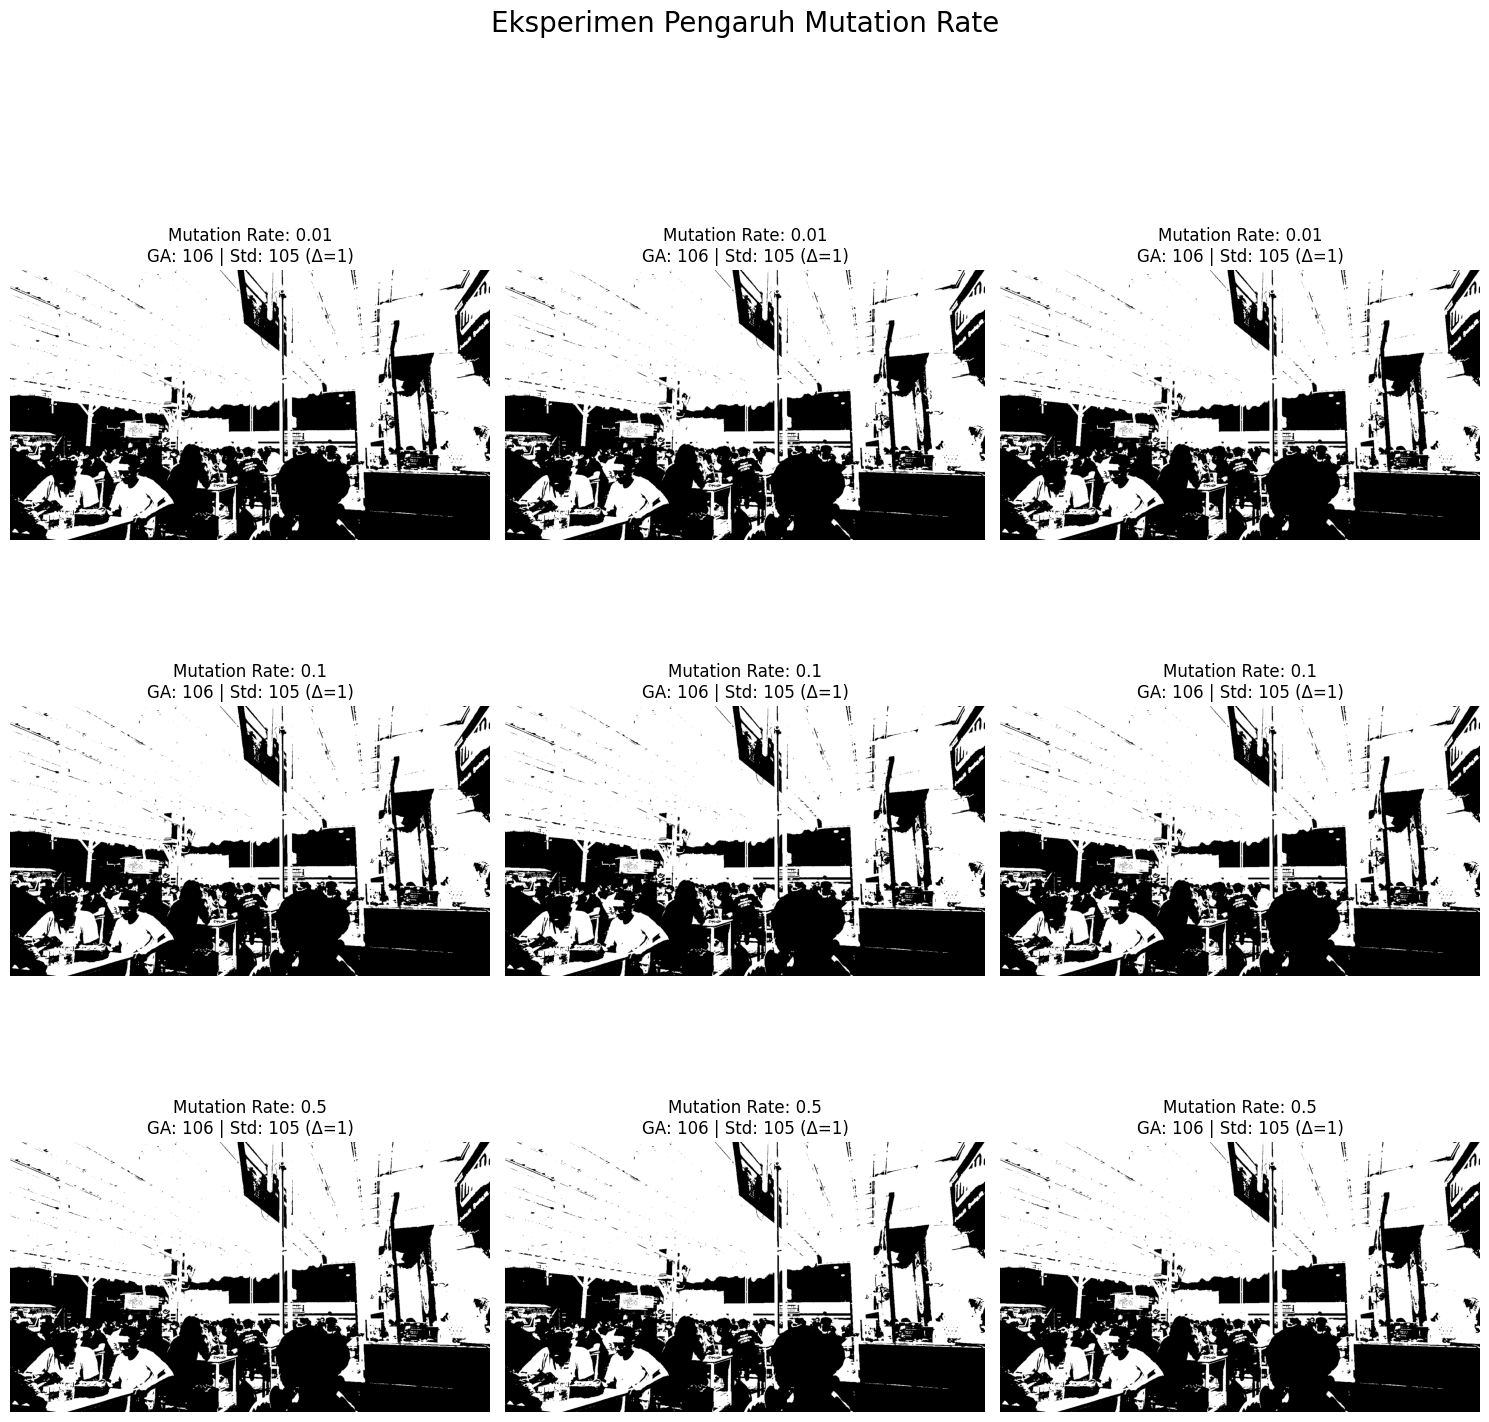


===== Memulai Eksperimen: population_size =====
  -> Menguji nilai: 10
     Run 1/3, Threshold: 107
     Run 2/3, Threshold: 106
     Run 3/3, Threshold: 108
  -> Menguji nilai: 50
     Run 1/3, Threshold: 106
     Run 2/3, Threshold: 106
     Run 3/3, Threshold: 106
  -> Menguji nilai: 200
     Run 1/3, Threshold: 106
     Run 2/3, Threshold: 106
     Run 3/3, Threshold: 106


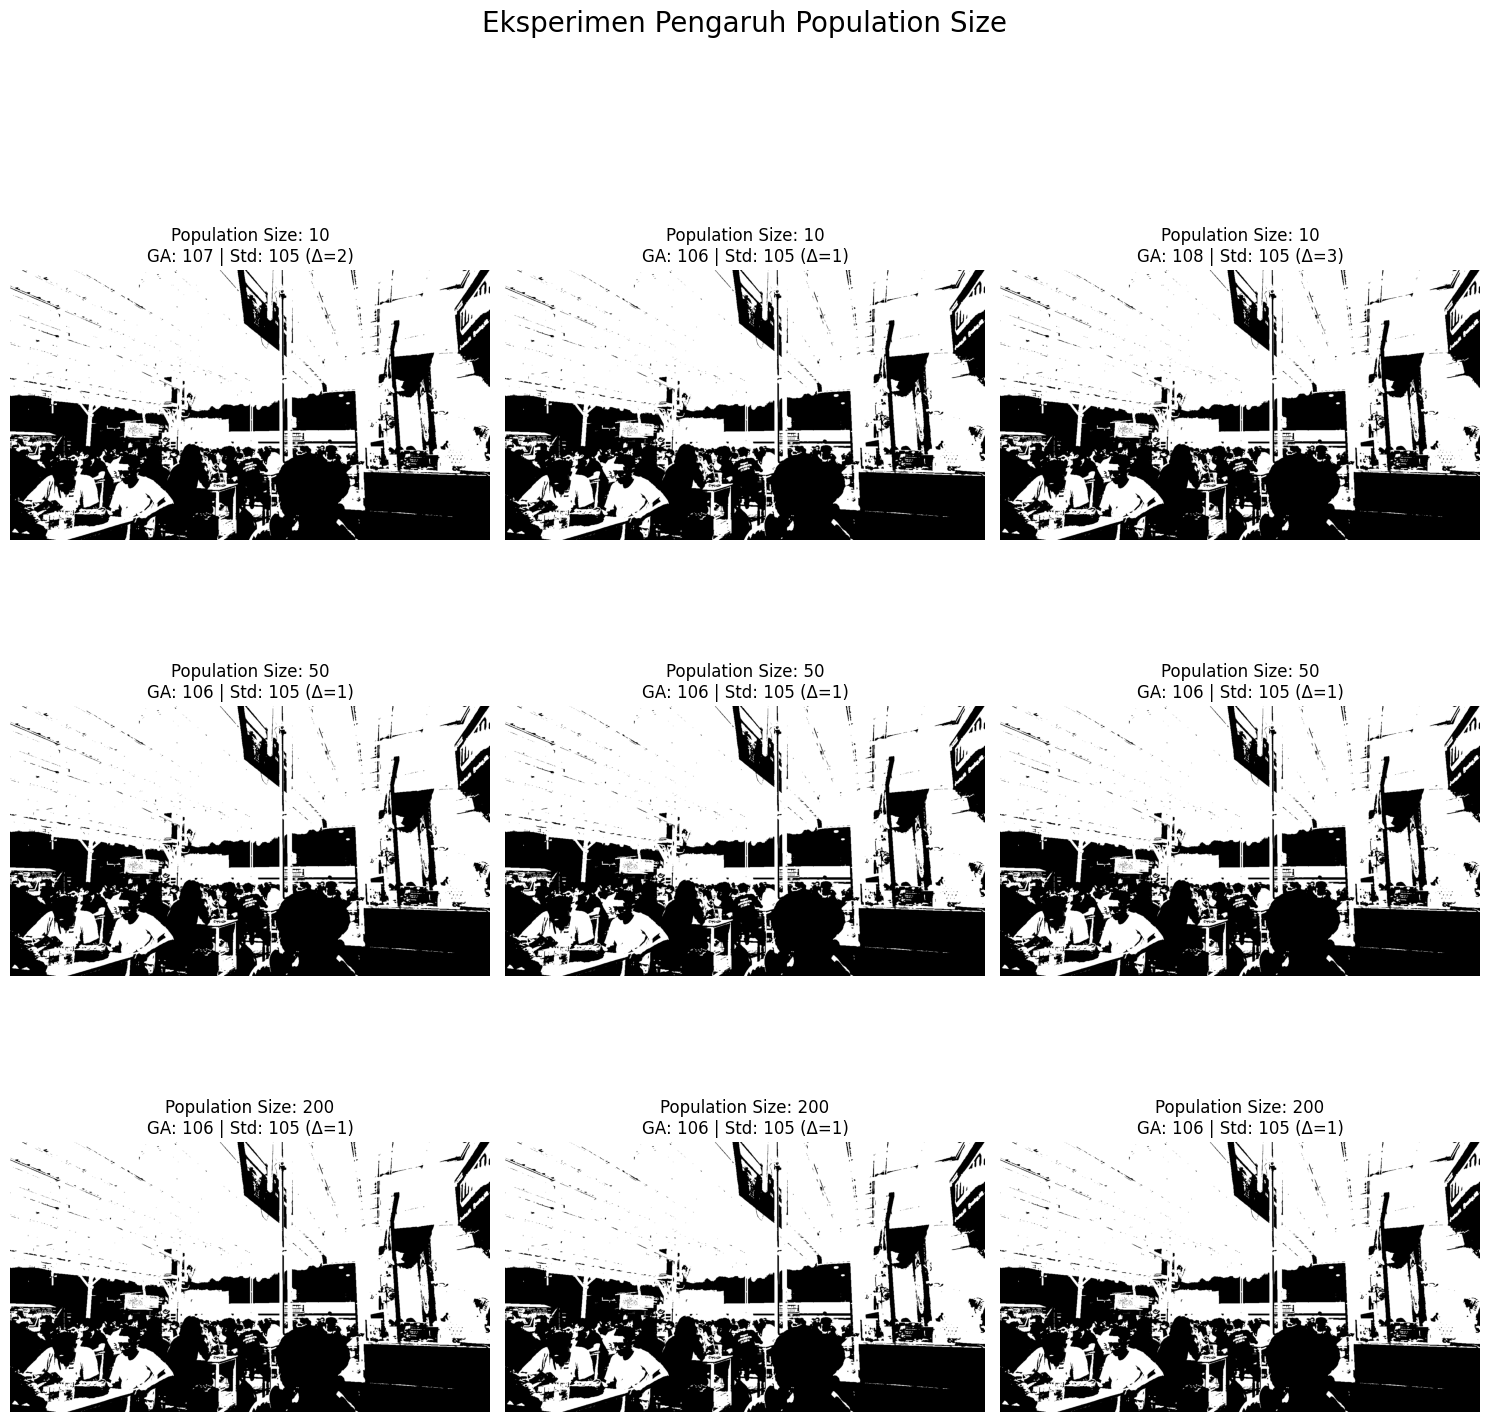


===== Memulai Eksperimen: generations =====
  -> Menguji nilai: 10
     Run 1/3, Threshold: 106
     Run 2/3, Threshold: 106
     Run 3/3, Threshold: 106
  -> Menguji nilai: 50
     Run 1/3, Threshold: 106
     Run 2/3, Threshold: 106
     Run 3/3, Threshold: 106
  -> Menguji nilai: 150
     Run 1/3, Threshold: 106
     Run 2/3, Threshold: 106
     Run 3/3, Threshold: 106


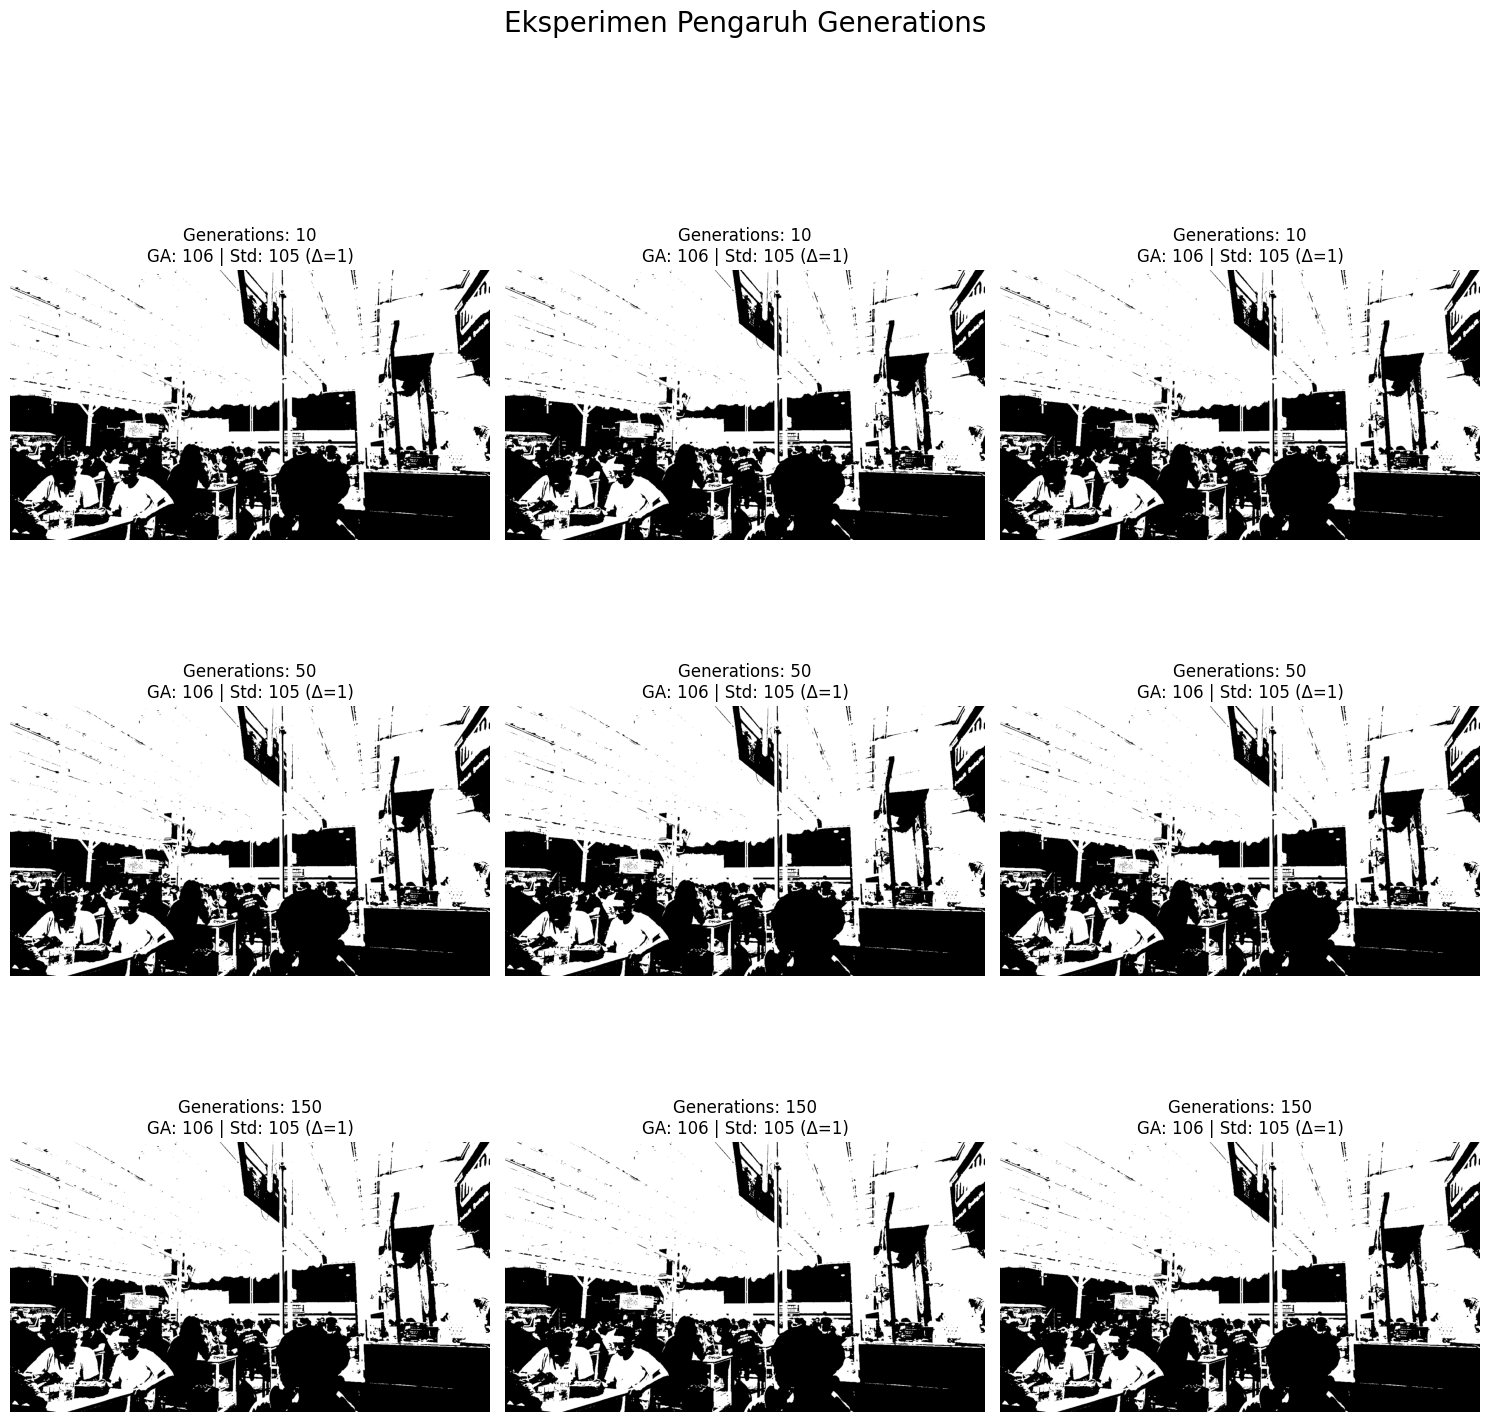

In [12]:
import cv2
import numpy as np
import random
import time
import matplotlib.pyplot as plt

# =============================================================================
# BAGIAN 1: FUNGSI-FUNGSI INTI GENETIC ALGORITHM (TIDAK BERUBAH)
# =============================================================================
# (Fungsi-fungsi inti GA diletakkan di sini, sama seperti kode sebelumnya)
def calculate_otsu_fitness(histogram, threshold):
    total_pixels = histogram.sum()
    if threshold < 1 or threshold > 254: return 0
    w0 = histogram[:threshold].sum()
    if w0 == 0: return 0
    p0 = w0 / total_pixels
    mean0 = np.sum(np.arange(threshold) * histogram[:threshold]) / w0
    w1 = histogram[threshold:].sum()
    if w1 == 0: return 0
    p1 = w1 / total_pixels
    mean1 = np.sum(np.arange(threshold, 256) * histogram[threshold:]) / w1
    return p0 * p1 * ((mean0 - mean1) ** 2)

def create_initial_population(size):
    return [format(random.randint(0, 255), '08b') for _ in range(size)]

def decode_chromosome(chromosome):
    return int(chromosome, 2)

def selection(population, fitness_scores):
    selected = []
    for _ in range(len(population)):
        tournament = random.sample(list(enumerate(population)), 3)
        winner = max(tournament, key=lambda i: fitness_scores[i[0]])
        selected.append(winner[1])
    return selected

def crossover(parent1, parent2):
    point = random.randint(1, 7)
    return parent1[:point] + parent2[point:], parent2[:point] + parent1[point:]

def mutate(chromosome, mutation_rate):
    mutated_chromosome = list(chromosome)
    for i in range(len(mutated_chromosome)):
        if random.random() < mutation_rate:
            mutated_chromosome[i] = '1' if mutated_chromosome[i] == '0' else '0'
    return "".join(mutated_chromosome)

def run_genetic_algorithm(histogram, pop_size, generations, mutation_rate):
    population = create_initial_population(pop_size)
    best_threshold_in_run = -1
    best_fitness_in_run = -1
    for _ in range(generations):
        fitness_scores = [calculate_otsu_fitness(hist, decode_chromosome(ind)) for ind in population]
        current_best_fitness = max(fitness_scores)
        if current_best_fitness > best_fitness_in_run:
            best_fitness_in_run = current_best_fitness
            best_threshold_in_run = decode_chromosome(population[fitness_scores.index(best_fitness_in_run)])
        parents = selection(population, fitness_scores)
        next_population = []
        for i in range(0, pop_size, 2):
            child1, child2 = crossover(parents[i], parents[i+1])
            next_population.append(mutate(child1, mutation_rate))
            next_population.append(mutate(child2, mutation_rate))
        population = next_population
    return best_threshold_in_run

# =============================================================================
# BAGIAN 2: FUNGSI HELPER EKSPERIMEN (DENGAN PERBAIKAN)
# =============================================================================

# #### PERUBAHAN 1: Menambahkan parameter 'standard_otsu_thresh' ####
def run_and_display_experiment(img, hist, baseline_params, param_to_test_name, test_values, standard_otsu_thresh, runs_per_value=3):
    """
    Fungsi untuk menjalankan satu set eksperimen dan menampilkan hasilnya dalam satu grid.
    """
    print(f"\n{'='*50}\n===== Memulai Eksperimen: {param_to_test_name} =====\n{'='*50}")

    results_images = {val: [] for val in test_values}
    results_thresholds = {val: [] for val in test_values}

    for value in test_values:
        print(f"  -> Menguji nilai: {value}")
        current_params = baseline_params.copy()
        current_params[param_to_test_name] = value

        for run in range(runs_per_value):
            threshold = run_genetic_algorithm(
                hist,
                pop_size=current_params['population_size'],
                generations=current_params['generations'],
                mutation_rate=current_params['mutation_rate']
            )
            _, result_img = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY)
            results_images[value].append(result_img)
            results_thresholds[value].append(threshold)
            print(f"     Run {run+1}/{runs_per_value}, Threshold: {threshold}")

    # Menampilkan hasil
    fig, axes = plt.subplots(len(test_values), runs_per_value, figsize=(5 * runs_per_value, 5 * len(test_values)))
    fig.suptitle(f'Eksperimen Pengaruh {param_to_test_name.replace("_", " ").title()}', fontsize=20, y=1.03)

    for i, value in enumerate(test_values):
        for j in range(runs_per_value):
            ax = axes[i, j] if len(test_values) > 1 else axes[j]
            ax.imshow(results_images[value][j], cmap='gray')

            # #### PERUBAHAN 2: Modifikasi judul plot untuk perbandingan langsung ####
            ga_thresh = results_thresholds[value][j]
            delta = abs(ga_thresh - standard_otsu_thresh)
            title_text = (f"{param_to_test_name.replace('_', ' ').title()}: {value}\n"
                          f"GA: {ga_thresh} | Std: {standard_otsu_thresh} (Δ={delta})")
            ax.set_title(title_text)
            ax.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

# =============================================================================
# BAGIAN 3: EKSEKUSI UTAMA (DENGAN PERBAIKAN)
# =============================================================================

if __name__ == "__main__":
    IMAGE_PATH = '/content/high_kompleks.jpeg' # GANTI DENGAN PATH GAMBAR ANDA!
    RUNS_PER_VALUE = 3

    BASELINE_PARAMETERS = {
        'population_size': 50,
        'generations': 50,
        'mutation_rate': 0.02
    }

    MUTATION_VALUES = [0.01, 0.1, 0.5]
    POPULATION_VALUES = [10, 50, 200]
    GENERATION_VALUES = [10, 50, 150]

    try:
        img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
        if img is None: raise FileNotFoundError(f"Tidak dapat menemukan gambar di: {IMAGE_PATH}")
        hist = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()

        # Hitung Otsu standar SEKALI saja di sini
        otsu_std_thresh, otsu_std_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        # Konversi ke integer untuk tampilan yang bersih
        otsu_std_thresh = int(otsu_std_thresh)

        # Tampilkan acuan utama
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Gambar Asli'); plt.axis('off')
        plt.subplot(1, 2, 2); plt.imshow(otsu_std_img, cmap='gray'); plt.title(f'Standar OpenCV Otsu (Thresh: {otsu_std_thresh})'); plt.axis('off')
        plt.show()

    except FileNotFoundError as e:
        print(e)
        exit()

    # --- Menjalankan Semua Eksperimen ---
    # #### PERUBAHAN 3: Memasukkan 'otsu_std_thresh' saat memanggil fungsi ####

    # Eksperimen 1: Menguji Tingkat Mutasi
    run_and_display_experiment(img, hist, BASELINE_PARAMETERS, 'mutation_rate', MUTATION_VALUES, otsu_std_thresh, RUNS_PER_VALUE)

    # Eksperimen 2: Menguji Ukuran Populasi
    run_and_display_experiment(img, hist, BASELINE_PARAMETERS, 'population_size', POPULATION_VALUES, otsu_std_thresh, RUNS_PER_VALUE)

    # Eksperimen 3: Menguji Jumlah Generasi
    run_and_display_experiment(img, hist, BASELINE_PARAMETERS, 'generations', GENERATION_VALUES, otsu_std_thresh, RUNS_PER_VALUE)